In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

In [32]:
df = pd.read_csv("../data/kenya.csv")

df["Country"] = "Kenya"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


In [33]:
df.replace(-999, np.nan, inplace=True)

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_report

,Missing Count,Missing Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Value Analysis

- The dataset was checked for missing values by replacing -999 with NaN.
- Missing value counts and percentages were calculated for each column.
- This helps determine whether any column requires cleaning before analysis.

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Summary Statistics Interpretation

- The average temperature (T2M) in Kenya is around 20°C, indicating a warmer climate compared to Ethiopia.
- Rainfall shows variability, with some days having no rain and others experiencing moderate to heavy rainfall.
- Humidity levels are relatively high, suggesting a moist tropical climate.
- Wind speed remains moderate, indicating stable atmospheric conditions.

In [36]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [37]:
from scipy import stats

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols]))
# z = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z > 3)

outliers.sum()

np.int64(124)

### Outlier Detection

- A total of 124 extreme values were detected using Z-score > 3.
- These values represent unusual climate conditions such as heavy rainfall or extreme temperatures.
- Outliers are retained as they reflect real-world environmental variations.

In [38]:
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


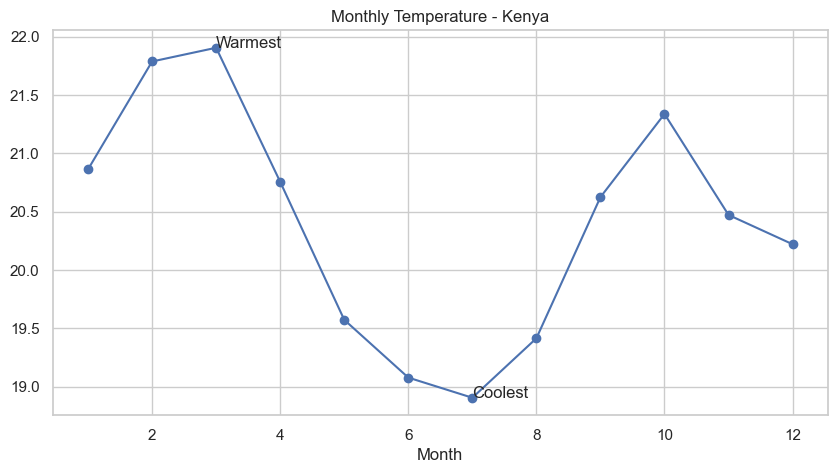

In [39]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker="o")

plt.annotate("Warmest", xy=(warmest, monthly_temp.max()))
plt.annotate("Coolest", xy=(coolest, monthly_temp.min()))

plt.title("Monthly Temperature - Kenya")
plt.show()

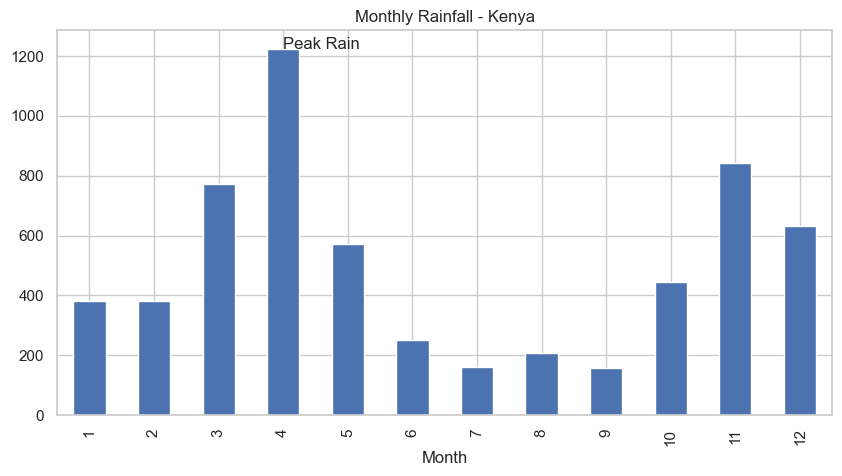

In [40]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

peak = monthly_rain.idxmax()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")

plt.annotate("Peak Rain", xy=(peak-1, monthly_rain.max()))

plt.title("Monthly Rainfall - Kenya")
plt.show()

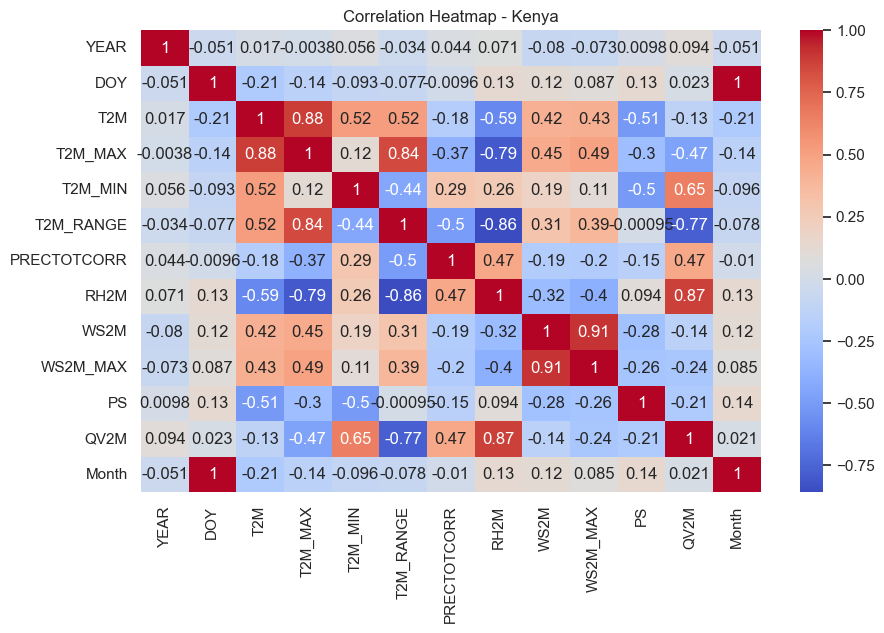

In [41]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Kenya")
plt.show()

### Correlation Analysis

- Strong positive correlation exists between WS2M and WS2M_MAX.
- Humidity (RH2M) is positively correlated with moisture (QV2M).
- Temperature range shows a negative relationship with humidity.

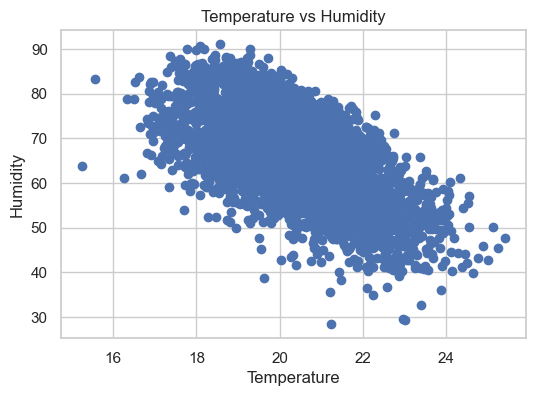

In [42]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

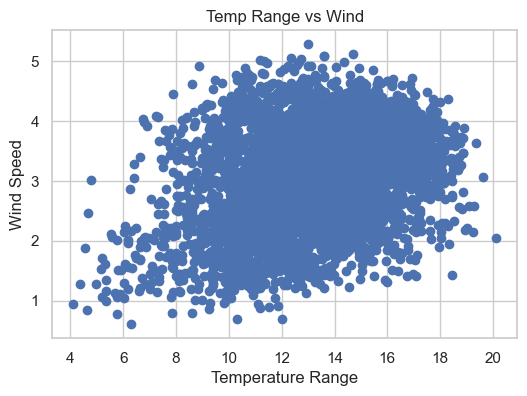

In [43]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind")
plt.show()

### Scatter Plot Analysis

- Temperature and humidity show a moderate inverse relationship.
- Temperature range and wind speed show weak dependency.

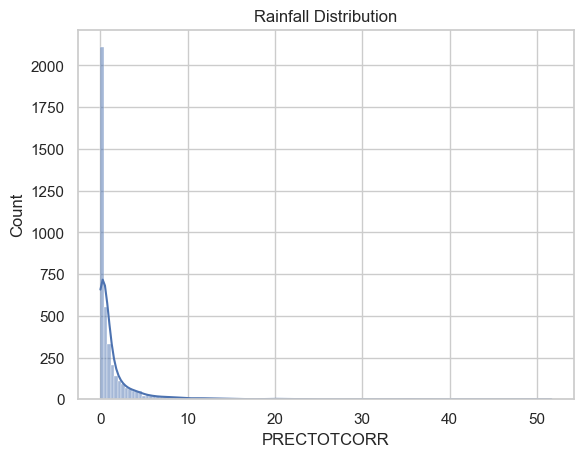

In [44]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.title("Rainfall Distribution")
plt.show()

### Rainfall Distribution

- Rainfall is right-skewed.
- Most days have low rainfall.
- Few days experience heavy rainfall.

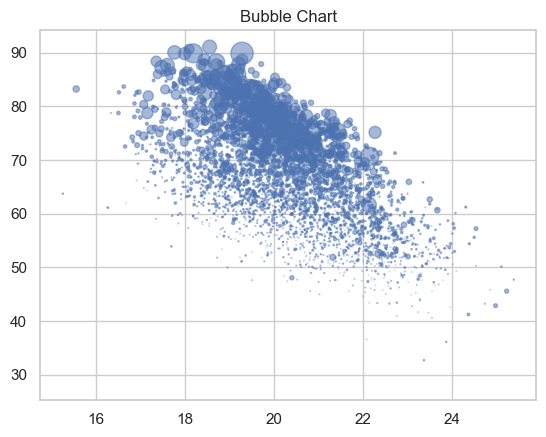

In [45]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*5, alpha=0.5)
plt.title("Bubble Chart")
plt.show()

### Bubble Chart Analysis

- Larger bubbles indicate higher rainfall.
- Rainfall tends to occur at higher humidity levels.
- Temperature has less direct impact on rainfall intensity.

In [47]:
df.to_csv("../data/kenya_clean.csv", index=False)